# Deteccion de Tumores (Benigno vs Maligno) con Red Neuronal

## Paso 1: Importar librerias

In [125]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    roc_curve,
)

import tensorflow as tf
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Dense, Dropout, Input
from tensorflow.keras.callbacks import EarlyStopping

# ===== CONFIGURAR SEMILLAS PARA REPRODUCIBILIDAD =====
SEED = 42
np.random.seed(SEED)
tf.random.set_seed(SEED)

print(f"TensorFlow: {tf.__version__}")
print(f"Pandas: {pd.__version__}")
print(f"NumPy: {np.__version__}")
print(f"\n✓ Semillas aleatorias configuradas (SEED={SEED})")

TensorFlow: 2.21.0
Pandas: 3.0.1
NumPy: 2.4.3

✓ Semillas aleatorias configuradas (SEED=42)


## Paso 2: Cargar y validar dataset local

In [126]:
df = pd.read_csv('Breast_cancer_Reseach.csv')

if 'diagnosis' not in df.columns:
    raise ValueError("El dataset debe contener la columna 'diagnosis' con valores B/M")

df['diagnosis'] = df['diagnosis'].astype(str).str.strip().str.upper()
df['target'] = df['diagnosis'].map({'B': 0, 'M': 1})

if df['target'].isna().any():
    invalidos = sorted(df.loc[df['target'].isna(), 'diagnosis'].unique())
    raise ValueError(f"Se encontraron etiquetas invalidas en diagnosis: {invalidos}")

feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

print('Dataset cargado correctamente')
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Features usadas: {len(feature_cols)}")
print('Mapeo target: 0=Benigno, 1=Maligno')

df.head()

Dataset cargado correctamente
Filas: 1200
Columnas: 23
Features usadas: 21
Mapeo target: 0=Benigno, 1=Maligno


,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave_points_mean,symmetry_mean,fractal_dimension_mean,...,area_se,smoothness_se,radius_worst,texture_worst,perimeter_worst,area_worst,concavity_worst,concave_points_worst,diagnosis,target
0,15.490142,19.500898,75.565249,526.409677,0.110140,0.094296,0.211172,0.109355,0.114075,0.054322,...,42.305337,0.011282,18.287341,22.645848,101.643449,980.949501,0.300743,0.116431,B,0
1,13.585207,17.282378,93.536417,542.133582,0.098852,0.118453,0.205202,0.146600,0.218061,0.065125,...,32.253159,0.007029,13.874569,27.706897,120.003792,734.421427,0.292429,0.114310,B,0
2,15.943066,19.489190,79.066398,957.471814,0.072091,0.102897,0.265062,0.125013,0.185707,0.062901,...,61.427110,0.007098,19.765426,23.100544,165.333024,865.634991,0.138234,0.221270,B,0
3,18.569090,21.173192,84.566898,650.102423,0.085842,0.122600,0.132492,0.093229,0.168611,0.060439,...,54.395979,0.005667,14.638553,25.579304,101.911156,808.195350,0.218719,0.243221,M,1
4,13.297540,19.195440,123.469042,767.319500,0.094745,0.139292,0.060506,0.154095,0.205715,0.069305,...,32.581794,0.007993,19.998220,25.872578,89.016818,987.071625,0.520519,0.103556,M,1


## Paso 3: Limpieza de datos

In [127]:
print('=== Limpieza de datos ===\n')

# Verificar duplicados
duplicados_antes = df.duplicated().sum()
print(f"Filas duplicadas encontradas: {duplicados_antes}")

if duplicados_antes > 0:
    df = df.drop_duplicates()
    print(f"  -> Eliminadas {duplicados_antes} filas duplicadas")

# Verificar valores nulos
nulos_por_columna = df.isnull().sum()
nulos_totales = nulos_por_columna.sum()
print(f"\nValores nulos por columna: {nulos_totales}")

if nulos_totales > 0:
    print("\nColumnas con valores nulos:")
    print(nulos_por_columna[nulos_por_columna > 0])
    
    # Opción 1: Eliminar filas con nulos (si son pocos)
    if nulos_totales < len(df) * 0.05:  # menos del 5%
        df = df.dropna()
        print(f"  -> Eliminadas filas con valores nulos")
    else:
        # Opción 2: Imputar con la mediana (para features numéricas)
        for col in feature_cols:
            if df[col].isnull().sum() > 0:
                mediana = df[col].median()
                df[col].fillna(mediana, inplace=True)
                print(f"  -> Imputados valores nulos en '{col}' con mediana: {mediana:.4f}")

# Verificar outliers extremos usando IQR
print(f"\n=== Detección de outliers (método IQR) ===")
outliers_totales = 0

for col in feature_cols[:5]:  # Revisar las primeras 5 features como ejemplo
    Q1 = df[col].quantile(0.25)
    Q3 = df[col].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 3 * IQR  # factor 3 para outliers extremos
    upper_bound = Q3 + 3 * IQR
    
    outliers = ((df[col] < lower_bound) | (df[col] > upper_bound)).sum()
    if outliers > 0:
        print(f"{col}: {outliers} outliers extremos detectados")
        outliers_totales += outliers

if outliers_totales == 0:
    print("No se detectaron outliers extremos en las features principales")

print(f"\n=== Dataset después de limpieza ===")
print(f"Filas: {df.shape[0]}")
print(f"Columnas: {df.shape[1]}")
print(f"Valores nulos restantes: {df.isnull().sum().sum()}")

# Actualizar feature_cols en caso de que se hayan eliminado columnas
feature_cols = [c for c in df.columns if c not in ['diagnosis', 'target']]

=== Limpieza de datos ===

Filas duplicadas encontradas: 0

Valores nulos por columna: 0

=== Detección de outliers (método IQR) ===
No se detectaron outliers extremos en las features principales

=== Dataset después de limpieza ===
Filas: 1200
Columnas: 23
Valores nulos restantes: 0


=== Normalización de datos ===

Normalización aplicada a 21 features

Rango de valores después de normalización:
  Mínimo: 0.0000
  Máximo: 1.0000
  Media: 0.4905


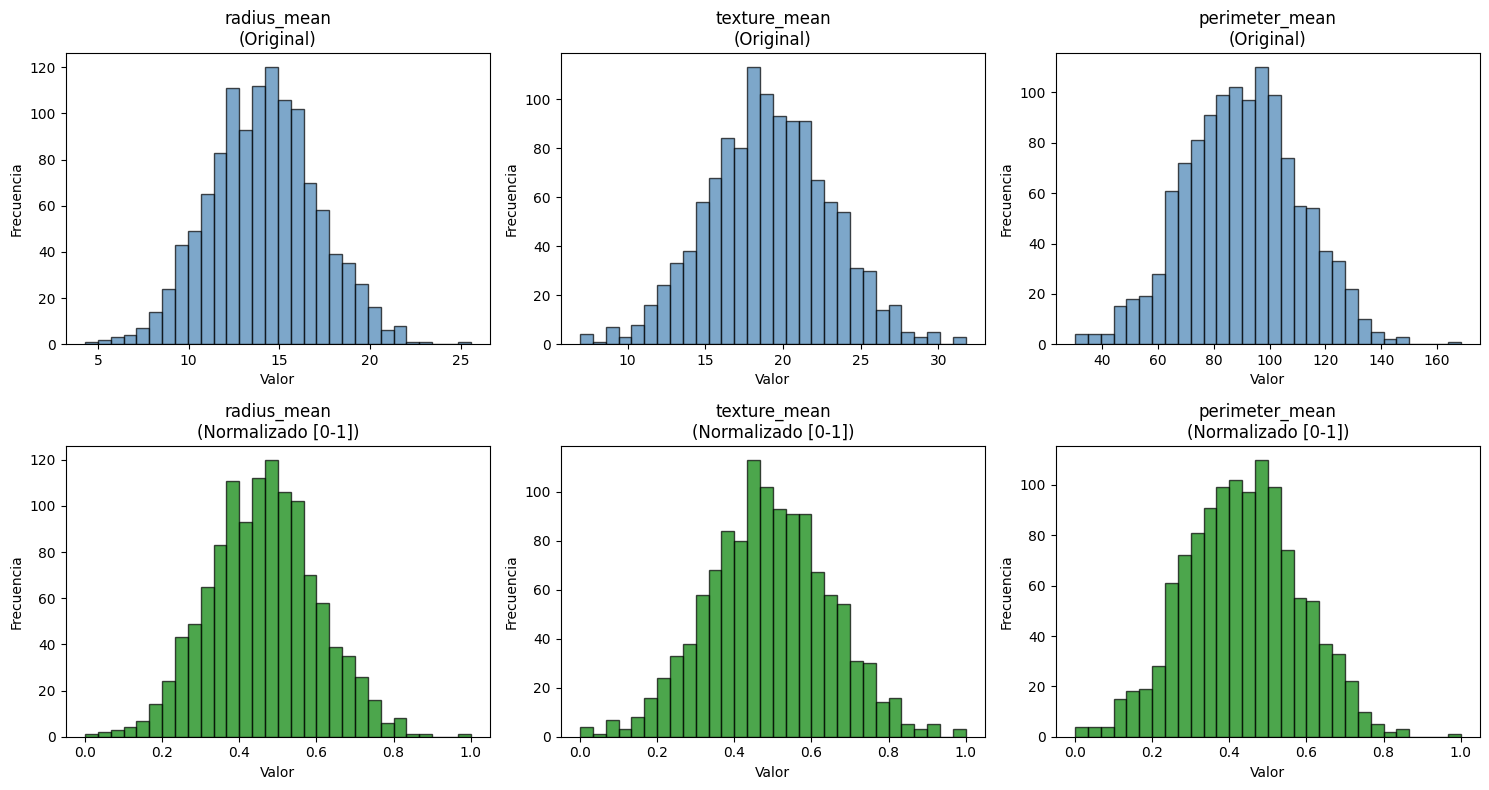


=== Dataset normalizado ===
Filas: 1200
Features normalizadas: 21


In [128]:
print('=== Normalización de datos ===\n')

# Normalizar las features numéricas al rango [0, 1]
normalizer = MinMaxScaler()

# Normalizar solo las columnas de features (no diagnosis ni target)
df_normalized = df.copy()
df_normalized[feature_cols] = normalizer.fit_transform(df[feature_cols])

print(f"Normalización aplicada a {len(feature_cols)} features")
print(f"\nRango de valores después de normalización:")
print(f"  Mínimo: {df_normalized[feature_cols].min().min():.4f}")
print(f"  Máximo: {df_normalized[feature_cols].max().max():.4f}")
print(f"  Media: {df_normalized[feature_cols].mean().mean():.4f}")

# Visualizar comparación antes y después (primeras 3 features)
fig, axes = plt.subplots(2, 3, figsize=(15, 8))

for idx, col in enumerate(feature_cols[:3]):
    # Antes de normalizar
    axes[0, idx].hist(df[col], bins=30, color='steelblue', alpha=0.7, edgecolor='black')
    axes[0, idx].set_title(f'{col}\n(Original)')
    axes[0, idx].set_xlabel('Valor')
    axes[0, idx].set_ylabel('Frecuencia')
    
    # Después de normalizar
    axes[1, idx].hist(df_normalized[col], bins=30, color='green', alpha=0.7, edgecolor='black')
    axes[1, idx].set_title(f'{col}\n(Normalizado [0-1])')
    axes[1, idx].set_xlabel('Valor')
    axes[1, idx].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

# Actualizar el DataFrame principal con los datos normalizados
df = df_normalized.copy()

print(f"\n=== Dataset normalizado ===")
print(f"Filas: {df.shape[0]}")
print(f"Features normalizadas: {len(feature_cols)}")

## Paso 4: Normalización de datos

## Paso 5: Analisis exploratorio rapido

Valores nulos totales: 0
Benigno (0): 612
Maligno (1): 588


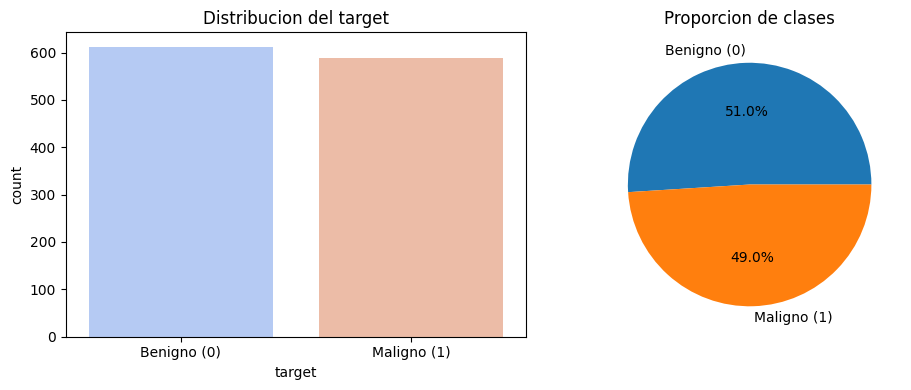

In [129]:
print('Valores nulos totales:', df.isnull().sum().sum())

conteo = df['target'].value_counts().sort_index()
print(f"Benigno (0): {conteo.get(0, 0)}")
print(f"Maligno (1): {conteo.get(1, 0)}")

plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.countplot(x='target', data=df, hue='target', palette='coolwarm', legend=False)
plt.title('Distribucion del target')
plt.xticks([0, 1], ['Benigno (0)', 'Maligno (1)'])

plt.subplot(1, 2, 2)
df['target'].value_counts().sort_index().plot(kind='pie', autopct='%1.1f%%', labels=['Benigno (0)', 'Maligno (1)'])
plt.ylabel('')
plt.title('Proporcion de clases')

plt.tight_layout()
plt.show()

## Paso 6: Preprocesamiento (train/val/test estratificado)

In [130]:
X = df[feature_cols].copy()
y = df['target'].copy()

# Los datos ya están normalizados en el rango [0,1] del Paso 4
print('Datos ya normalizados - Rango de valores:')
print(f"  Mínimo: {X.min().min():.4f}")
print(f"  Máximo: {X.max().max():.4f}\n")

X_temp, X_test, y_temp, y_test = train_test_split(
    X, y, test_size=0.20, random_state=42, stratify=y
)

X_train, X_val, y_train, y_val = train_test_split(
    X_temp, y_temp, test_size=0.20, random_state=42, stratify=y_temp
)

print(f"Train: {X_train.shape}, Validation: {X_val.shape}, Test: {X_test.shape}")

# Convertir a numpy arrays (los datos ya están normalizados, no se necesita StandardScaler)
X_train_scaled = X_train.to_numpy()
X_val_scaled = X_val.to_numpy()
X_test_scaled = X_test.to_numpy()

y_train = y_train.to_numpy()
y_val = y_val.to_numpy()
y_test = y_test.to_numpy()

print('\nDatos preparados para entrenamiento')
print(f"Media train: {X_train_scaled.mean():.4f}")
print(f"Std train: {X_train_scaled.std():.4f}")
print(f"Rango: [{X_train_scaled.min():.4f}, {X_train_scaled.max():.4f}]")

Datos ya normalizados - Rango de valores:
  Mínimo: 0.0000
  Máximo: 1.0000

Train: (768, 21), Validation: (192, 21), Test: (240, 21)

Datos preparados para entrenamiento
Media train: 0.4904
Std train: 0.1569
Rango: [0.0000, 1.0000]


## Paso 7: Crear y entrenar la red neuronal

In [131]:
num_features = X_train_scaled.shape[1]

model = Sequential([
    Input(shape=(num_features,)),
    Dense(64, activation='relu'),
    Dropout(0.30),
    Dense(32, activation='relu'),
    Dropout(0.20),
    Dense(16, activation='relu'),
    Dropout(0.10),
    Dense(1, activation='sigmoid'),
])

model.compile(
    optimizer='adam',
    loss='binary_crossentropy',
    metrics=['accuracy'],
)

early_stop = EarlyStopping(
    monitor='val_loss',
    patience=15,
    restore_best_weights=True,
    verbose=1,
)

history = model.fit(
    X_train_scaled,
    y_train,
    validation_data=(X_val_scaled, y_val),
    epochs=100,
    batch_size=32,
    callbacks=[early_stop],
    verbose=1,
)

print('Entrenamiento finalizado')
print(f"Epochs ejecutados: {len(history.history['loss'])}")

Epoch 1/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 2s 17ms/step - accuracy: 0.5365 - loss: 0.6918 - val_accuracy: 0.4531 - val_loss: 0.6961
Epoch 2/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.5169 - loss: 0.6917 - val_accuracy: 0.4375 - val_loss: 0.6957
Epoch 3/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.4987 - loss: 0.6992 - val_accuracy: 0.4219 - val_loss: 0.6960
Epoch 4/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 7ms/step - accuracy: 0.4831 - loss: 0.6964 - val_accuracy: 0.4427 - val_loss: 0.6958
Epoch 5/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 11ms/step - accuracy: 0.5221 - loss: 0.6904 - val_accuracy: 0.4792 - val_loss: 0.6960
Epoch 6/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 10ms/step - accuracy: 0.5039 - loss: 0.6936 - val_accuracy: 0.5208 - val_loss: 0.6963
Epoch 7/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5391 - loss: 0.6899 - val_accuracy: 0.5260 - val_loss: 0.6969
Epoch 8/100
24/24 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.5221 - loss: 0.6911 - val_accuracy: 0.5156 

## Paso 8: Evaluacion del modelo

In [132]:
y_pred_prob = model.predict(X_test_scaled).flatten()
y_pred = (y_pred_prob >= 0.5).astype(int)

accuracy = accuracy_score(y_test, y_pred)
precision = precision_score(y_test, y_pred)
recall = recall_score(y_test, y_pred)
f1 = f1_score(y_test, y_pred)
roc_auc = roc_auc_score(y_test, y_pred_prob)

print(f"Accuracy:  {accuracy:.4f}")
print(f"Precision: {precision:.4f}")
print(f"Recall:    {recall:.4f}")
print(f"F1-score:  {f1:.4f}")
print(f"ROC-AUC:   {roc_auc:.4f}")

print('\nReporte de clasificacion:')
print(classification_report(y_test, y_pred, target_names=['Benigno (0)', 'Maligno (1)']))

8/8 ━━━━━━━━━━━━━━━━━━━━ 0s 15ms/step
Accuracy:  0.4667
Precision: 0.4528
Recall:    0.4068
F1-score:  0.4286
ROC-AUC:   0.4751

Reporte de clasificacion:
              precision    recall  f1-score   support

 Benigno (0)       0.48      0.52      0.50       122
 Maligno (1)       0.45      0.41      0.43       118

    accuracy                           0.47       240
   macro avg       0.47      0.47      0.46       240
weighted avg       0.47      0.47      0.46       240



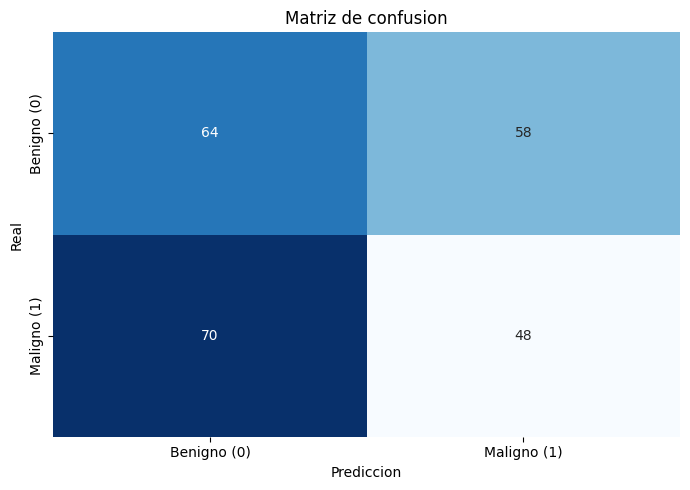

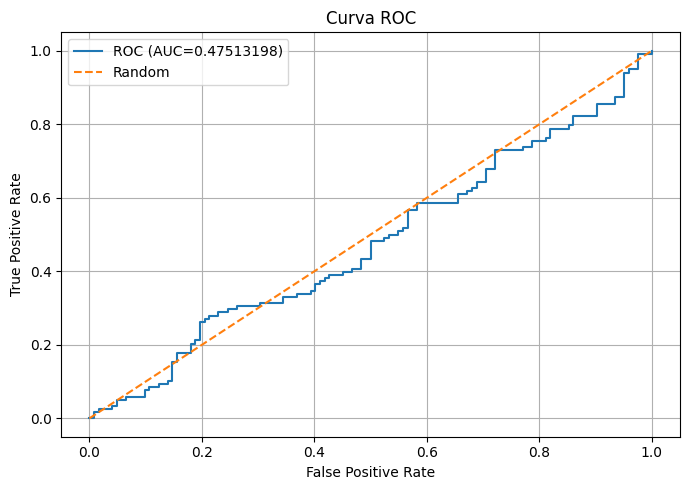

In [133]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(7, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title('Matriz de confusion')
plt.xlabel('Prediccion')
plt.ylabel('Real')
plt.xticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.yticks([0.5, 1.5], ['Benigno (0)', 'Maligno (1)'])
plt.tight_layout()
plt.show()

fpr, tpr, _ = roc_curve(y_test, y_pred_prob)
plt.figure(figsize=(7, 5))
plt.plot(fpr, tpr, label=f'ROC (AUC={roc_auc:.8f})')
plt.plot([0, 1], [0, 1], linestyle='--', label='Random')
plt.xlabel('False Positive Rate')
plt.ylabel('True Positive Rate')
plt.title('Curva ROC')
plt.legend()
plt.grid(True)
plt.tight_layout()
plt.show()

## Paso 9: Prediccion para nuevos parametros

In [134]:
TARGET_MAP = {0: 'Benigno', 1: 'Maligno'}

def predecir_tumor(parametros_entrada, modelo, normalizador, columnas_modelo, umbral=0.5):
    """
    parametros_entrada: dict con las features del dataset.
    modelo: modelo de red neuronal entrenado
    normalizador: MinMaxScaler usado en el Paso 4 para normalizar datos
    columnas_modelo: lista de nombres de features
    umbral: umbral de clasificación (default 0.5)
    """
    faltantes = [c for c in columnas_modelo if c not in parametros_entrada]
    if faltantes:
        raise ValueError(f'Faltan parametros: {faltantes}')

    x_df = pd.DataFrame([parametros_entrada], columns=columnas_modelo)
    x_normalized = normalizador.transform(x_df)

    prob_maligno = float(modelo.predict(x_normalized, verbose=0).flatten()[0])
    prob_benigno = 1.0 - prob_maligno
    pred = 1 if prob_maligno >= umbral else 0

    return {
        'prob_maligno': prob_maligno,
        'prob_benigno': prob_benigno,
        'pred_clase': pred,
        'pred_etiqueta': TARGET_MAP[pred],
    }

# Ejemplo de uso con los promedios del dataset
PARAMETROS_USUARIO = X.mean().to_dict()

resultado = predecir_tumor(
    PARAMETROS_USUARIO,
    modelo=model,
    normalizador=normalizer,  # Usar el normalizador del Paso 4
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print('=== Resultado de prediccion ===')
print(f"Prob. maligno: {resultado['prob_maligno']:.4f}")
print(f"Prob. benigno: {resultado['prob_benigno']:.4f}")
print(f"Clase predicha: {resultado['pred_clase']} -> {resultado['pred_etiqueta']}")

=== Resultado de prediccion ===
Prob. maligno: 0.0627
Prob. benigno: 0.9373
Clase predicha: 0 -> Benigno


In [135]:
# Diagnostico rapido de por que el modelo aprende
corr_abs = df[feature_cols + ['target']].corr(numeric_only=True)['target'].drop('target').abs().sort_values(ascending=False)

print('Top 10 correlaciones absolutas con target:')
print(corr_abs.head(10))
print(f'\nCorrelacion maxima abs: {corr_abs.max():.4f}')
print(f'Correlacion media abs: {corr_abs.mean():.4f}')

print('\nDistribucion de clases en dataset completo:')
print(df['target'].value_counts(normalize=True).sort_index())

print('\nValores minimos por feature (primeras 10):')
print(df[feature_cols].min().head(10))

Top 10 correlaciones absolutas con target:
area_mean                 0.077495
concavity_worst           0.047740
radius_worst              0.043308
smoothness_mean           0.039395
area_worst                0.038161
fractal_dimension_mean    0.025154
radius_mean               0.023988
concave_points_worst      0.023732
texture_mean              0.019890
perimeter_worst           0.018607
Name: target, dtype: float64

Correlacion maxima abs: 0.0775
Correlacion media abs: 0.0215

Distribucion de clases en dataset completo:
target
0    0.51
1    0.49
Name: proportion, dtype: float64

Valores minimos por feature (primeras 10):
radius_mean               0.0
texture_mean              0.0
perimeter_mean            0.0
area_mean                 0.0
smoothness_mean           0.0
compactness_mean          0.0
concavity_mean            0.0
concave_points_mean       0.0
symmetry_mean             0.0
fractal_dimension_mean    0.0
dtype: float64


## Paso 10: Ingresar datos personalizados

Modifica los valores en el diccionario `MIS_DATOS` con tus propios valores.
Los rangos mostrados son los valores minimos y maximos del dataset de entrenamiento.

In [136]:
# Mostrar rangos de referencia del dataset original (antes de normalizar)
print("=" * 70)
print("RANGOS DE REFERENCIA (valores del dataset original)")
print("=" * 70)

# Cargar dataset original para mostrar rangos reales
df_ref = pd.read_csv('Breast_cancer_Reseach.csv')
feature_cols_ref = [c for c in df_ref.columns if c not in ['diagnosis', 'target']]

print(f"\n{'Feature':<30} {'Min':>12} {'Max':>12} {'Promedio':>12}")
print("-" * 70)
for col in feature_cols_ref:
    print(f"{col:<30} {df_ref[col].min():>12.4f} {df_ref[col].max():>12.4f} {df_ref[col].mean():>12.4f}")

print("\n" + "=" * 70)

RANGOS DE REFERENCIA (valores del dataset original)

Feature                                 Min          Max     Promedio
----------------------------------------------------------------------
radius_mean                          4.2762      25.5582      14.1151
texture_mean                         6.9220      31.7724      19.0986
perimeter_mean                      30.1773     168.5248      90.3353
area_mean                          173.4944    1136.4639     640.9501
smoothness_mean                      0.0420       0.1623       0.0993
compactness_mean                    -0.0111       0.3265       0.1488
concavity_mean                      -0.1069       0.4702       0.2015
concave_points_mean                 -0.0098       0.2263       0.1005
symmetry_mean                        0.0623       0.2674       0.1792
fractal_dimension_mean               0.0262       0.0938       0.0597
radius_se                            0.1217       0.7284       0.4027
texture_se                          

DATOS INGRESADOS
  radius_mean: 14.127
  texture_mean: 19.289
  perimeter_mean: 91.969
  area_mean: 654.889
  smoothness_mean: 0.096
  compactness_mean: 0.104
  concavity_mean: 0.089
  concave_points_mean: 0.049
  symmetry_mean: 0.181
  fractal_dimension_mean: 0.063
  radius_se: 0.405
  texture_se: 1.217
  perimeter_se: 2.866
  area_se: 40.337
  smoothness_se: 0.007
  radius_worst: 16.269
  texture_worst: 25.677
  perimeter_worst: 107.261
  area_worst: 880.583
  concavity_worst: 0.272
  concave_points_worst: 0.115

RESULTADO DE LA PREDICCION

  Probabilidad de BENIGNO:  51.48%
  Probabilidad de MALIGNO:  48.52%

  >>> DIAGNOSTICO: BENIGNO <<<



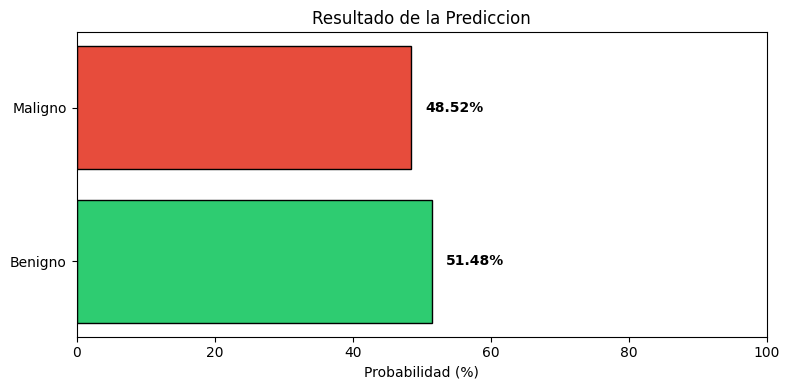

In [137]:
# ============================================================================
# INGRESA TUS DATOS PERSONALIZADOS AQUI
# ============================================================================
# Modifica los valores segun tus mediciones.
# Los valores por defecto son los promedios del dataset.

MIS_DATOS = {
    # ----- MEDIDAS MEAN (promedio de las celulas) -----
    'radius_mean':             14.127,    # Radio promedio
    'texture_mean':            19.289,    # Textura promedio
    'perimeter_mean':          91.969,    # Perimetro promedio
    'area_mean':               654.889,   # Area promedio
    'smoothness_mean':         0.096,     # Suavidad promedio
    'compactness_mean':        0.104,     # Compacidad promedio
    'concavity_mean':          0.089,     # Concavidad promedio
    'concave_points_mean':     0.049,     # Puntos concavos promedio
    'symmetry_mean':           0.181,     # Simetria promedio
    'fractal_dimension_mean':  0.063,     # Dimension fractal promedio
    
    # ----- MEDIDAS SE (error estandar) -----
    'radius_se':               0.405,     # Error del radio
    'texture_se':              1.217,     # Error de textura
    'perimeter_se':            2.866,     # Error del perimetro
    'area_se':                 40.337,    # Error del area
    'smoothness_se':           0.007,     # Error de suavidad
    
    # ----- MEDIDAS WORST (peor valor / mas grande) -----
    'radius_worst':            16.269,    # Peor radio
    'texture_worst':           25.677,    # Peor textura
    'perimeter_worst':         107.261,   # Peor perimetro
    'area_worst':              880.583,   # Peor area
    'concavity_worst':         0.272,     # Peor concavidad
    'concave_points_worst':    0.115,     # Peor puntos concavos
}

# ============================================================================
# EJECUTAR PREDICCION
# ============================================================================

print("=" * 70)
print("DATOS INGRESADOS")
print("=" * 70)
for key, value in MIS_DATOS.items():
    print(f"  {key}: {value}")

# Realizar prediccion
resultado = predecir_tumor(
    MIS_DATOS,
    modelo=model,
    normalizador=normalizer,
    columnas_modelo=feature_cols,
    umbral=0.5,
)

print("\n" + "=" * 70)
print("RESULTADO DE LA PREDICCION")
print("=" * 70)
print(f"\n  Probabilidad de BENIGNO:  {resultado['prob_benigno']*100:.2f}%")
print(f"  Probabilidad de MALIGNO:  {resultado['prob_maligno']*100:.2f}%")
print(f"\n  >>> DIAGNOSTICO: {resultado['pred_etiqueta'].upper()} <<<")
print("\n" + "=" * 70)

# Visualizacion
fig, ax = plt.subplots(figsize=(8, 4))
categorias = ['Benigno', 'Maligno']
probabilidades = [resultado['prob_benigno']*100, resultado['prob_maligno']*100]
colores = ['#2ecc71', '#e74c3c']

bars = ax.barh(categorias, probabilidades, color=colores, edgecolor='black')
ax.set_xlim(0, 100)
ax.set_xlabel('Probabilidad (%)')
ax.set_title('Resultado de la Prediccion')

for bar, prob in zip(bars, probabilidades):
    ax.text(prob + 2, bar.get_y() + bar.get_height()/2, f'{prob:.2f}%', 
            va='center', fontweight='bold')

plt.tight_layout()
plt.show()